# Solving differential equations
## 1. Runge–Kutta Method

Runge–Kutta methods are higher-order numerical schemes derived from Taylor series expansions to improve accuracy over basic methods like Euler. In this notebook, we focus on their implementation and validate their performance through error and convergence analysis.

The same example of radioactive decay is used and the methods of RK4 and RK5 are compared with exact value and Euler method value.


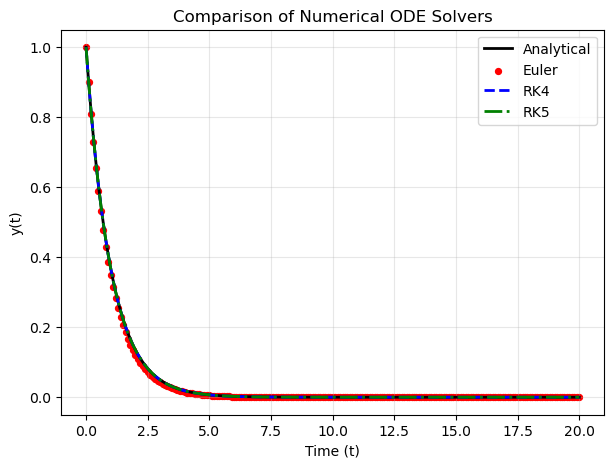

In [1]:
import sys
import os

sys.path.append("../src")
from euler import EulerODE
from rkmethods import rk4
from rkmethods import rk5

import numpy as np
import matplotlib.pyplot as plt
def f(t, y):
    return -y

t_1, y_1 = EulerODE(f, 0, 1, 200, 0.1)
t_2, y_2 = rk4(f, 0, 1, 200, 0.1)
t_3, y_3 = rk5(f, 0, 1, 200, 0.1)

t = t_1 # common time grid
y_exact = np.exp(-t)

plt.figure(figsize=(7,5))

# Analytical solution
plt.plot(t, y_exact,color='black',linewidth=2,label='Analytical')

# Euler solution
plt.scatter(t_1, y_1,color='red',s=18,label='Euler')

# RK4 solution
plt.plot(t_2, y_2,color='blue',linestyle='--',linewidth=2,label='RK4')

# RK5 solution
plt.plot(t_3, y_3,color='green',linestyle='-.',linewidth=2,label='RK5')

plt.xlabel("Time (t)")
plt.ylabel("y(t)")
plt.title("Comparison of Numerical ODE Solvers")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


We can see that all methods are accuarate for small h so its better to visualise their errors so as to analyse the differences better.

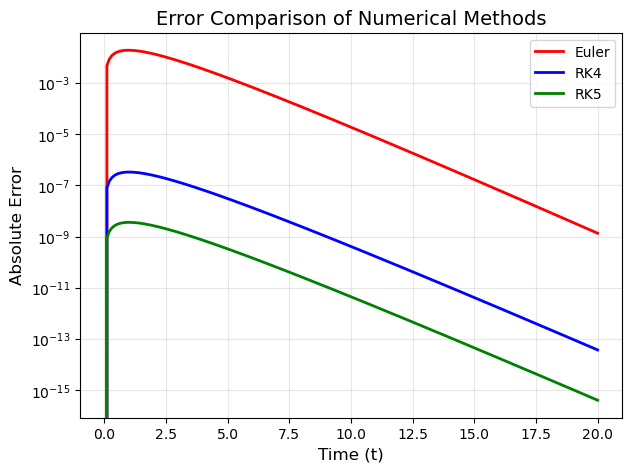

In [2]:
# Absolute errors
error_euler = np.abs(y_1 - y_exact)
error_rk4   = np.abs(y_2 - y_exact)
error_rk5   = np.abs(y_3 - y_exact)

plt.figure(figsize=(7,5))

plt.plot(t, error_euler,color='red',linewidth=2,label='Euler')

plt.plot(t, error_rk4,color='blue',linewidth=2,label='RK4')

plt.plot(t, error_rk5,color='green',linewidth=2,label='RK5')

plt.yscale('log')

plt.xlabel("Time (t)",fontsize=12)
plt.ylabel("Absolute Error",fontsize=12)
plt.title("Error Comparison of Numerical Methods",fontsize=14)

plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.savefig("../Images/errorcomparison.png", dpi=300, bbox_inches='tight')
plt.show()

Now it is very easy for us to distinguish between all the three methods. The error is more in euler and a less in rk4 and lower in rk5 when compared to each other. We can now try convergence plot too

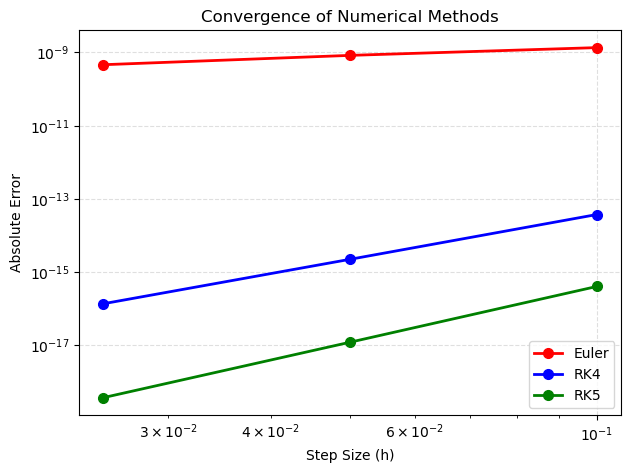

Euler order ≈ 0.78
RK4 order   ≈ 4.05
RK5 order   ≈ 5.04


In [3]:
# Step sizes
hs = [0.1, 0.05, 0.025]

# Error storage
error_1 = []   # Euler
error_2 = []   # RK4
error_3 = []   # RK5

T = 20

# Compute errors
for h in hs:

    n = int(T / h)

    t_1, y_1 = EulerODE(f, 0, 1, n, h)
    t_2, y_2 = rk4(f, 0, 1, n, h)
    t_3, y_3 = rk5(f, 0, 1, n, h)

    exact = np.exp(-20)

    error_1.append(np.abs(y_1[-1] - exact))
    error_2.append(np.abs(y_2[-1] - exact))
    error_3.append(np.abs(y_3[-1] - exact))

# Convergence plot
plt.figure(figsize=(7,5))

plt.loglog(hs, error_1,'o-',color='red',linewidth=2,markersize=7,label='Euler')

plt.loglog(hs, error_2,'o-',color='blue',linewidth=2,markersize=7,label='RK4')

plt.loglog(hs, error_3,'o-',color='green',linewidth=2,markersize=7,label='RK5')

plt.xlabel("Step Size (h)")
plt.ylabel("Absolute Error")
plt.title("Convergence of Numerical Methods")

plt.grid(True, linestyle='--', alpha=0.4)

plt.legend()

plt.show()

# Estimate order of accuracy
slope_1 = np.polyfit(np.log(hs), np.log(error_1), 1)[0]
slope_2 = np.polyfit(np.log(hs), np.log(error_2), 1)[0]
slope_3 = np.polyfit(np.log(hs), np.log(error_3), 1)[0]

# Print estimated orders
print(f"Euler order ≈ {slope_1:.2f}")
print(f"RK4 order   ≈ {slope_2:.2f}")
print(f"RK5 order   ≈ {slope_3:.2f}")


The computed convergence slopes closely match the theoretical orders of accuracy: first-order for Euler, fourth-order for RK4, and fifth-order for RK5.


## Conclusion

The function for RK4 and RK5 closely aligns with the analytical values and  higher-order Runge–Kutta methods significantly reduce global error compared to Euler’s method. Convergence analysis confirms theoretical orders.